**Task 1: Environment setup**

In [1]:
print("Hello, World!")

Hello, World!


**Task 2: Collect and Clean the OpenAlex Data**

In [2]:
import requests
import json
import time
from tqdm import tqdm

FSU_ID = "I103163165"

filter_string = f"authorships.institutions.id:{FSU_ID},publication_year:2021-2026"
select_fields = "id,doi,display_name,publication_year,publication_date,type,cited_by_count,authorships,primary_location,open_access,concepts"

base_url = "https://api.openalex.org/works"
cursor = "*"
records_saved = 0

with open("fsu_works_2021_2026.jsonl", "w") as f:
    with tqdm(unit="records") as pbar:
        while cursor is not None:
            params = {
                "filter": filter_string,
                "select": select_fields,
                "per-page": 200,
                "cursor": cursor
            }
            response = requests.get(base_url, params=params)
            data = response.json()

            for work in data["results"]:
                f.write(json.dumps(work) + "\n")
                records_saved += 1
                pbar.update(1)

            cursor = data["meta"]["next_cursor"]
            time.sleep(0.1)

print(f"Saved {records_saved} records to fsu_works_2021_2026.jsonl")

27733records [02:28, 187.02records/s]

Saved 27733 records to fsu_works_2021_2026.jsonl


In [3]:
def flatten_work(record):
    # basic top-level fields
    openalex_id = record.get("id")
    doi = record.get("doi")
    title = record.get("display_name")
    publication_year = record.get("publication_year")
    publication_date = record.get("publication_date")
    work_type = record.get("type")
    cited_by_count = record.get("cited_by_count")

    # venue info lives inside primary_location -> source
    primary_location = record.get("primary_location") or {}
    source = primary_location.get("source") or {}
    venue = source.get("display_name")
    venue_id = source.get("id")

    # open access info
    open_access = record.get("open_access") or {}
    is_oa = open_access.get("is_oa")
    oa_status = open_access.get("oa_status")

    # authors
    authorships = record.get("authorships") or []
    author_names = [a["author"]["display_name"] for a in authorships if a.get("author")]
    authors = "; ".join(author_names)
    n_authors = len(authorships)

    # fields/concepts
    concepts = record.get("concepts") or []
    if concepts:
        # pick the concept with the highest score as the primary field
        top_concept = max(concepts, key=lambda c: c["score"])
        primary_field = top_concept["display_name"]
    else:
        primary_field = None
    fields_all = "; ".join(c["display_name"] for c in concepts)

    return {
        "openalex_id": openalex_id,
        "doi": doi,
        "title": title,
        "publication_year": publication_year,
        "publication_date": publication_date,
        "type": work_type,
        "cited_by_count": cited_by_count,
        "venue": venue,
        "venue_id": venue_id,
        "is_oa": is_oa,
        "oa_status": oa_status,
        "authors": authors,
        "n_authors": n_authors,
        "primary_field": primary_field,
        "fields_all": fields_all
    }


flattened_records = []

with open("fsu_works_2021_2026.jsonl", "r") as f:
    for line in f:
        record = json.loads(line)
        flattened_records.append(flatten_work(record))

print(f"Flattened {len(flattened_records)} records")

Flattened 27733 records


In [4]:
import pandas as pd

df = pd.DataFrame(flattened_records)
df.to_csv("fsu_works_2021_2026.csv", index=False)

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 27733, Columns: 15


,openalex_id,doi,title,publication_year,publication_date,type,cited_by_count,venue,venue_id,is_oa,oa_status,authors,n_authors,primary_field,fields_all
0,https://openalex.org/W2963002078,https://doi.org/10.1093/ptep/ptac097,Review of Particle Physics,2022,2022-08-01,article,6045,Progress of Theoretical and Experimental Physics,https://openalex.org/S4210202364,True,gold,Particle Data Group; Ronald Workman; Volker Bu...,100,Physics,Physics; Particle physics; Higgs boson; Supers...
1,https://openalex.org/W4401211033,https://doi.org/10.1103/physrevd.110.030001,Review of Particle Physics,2024,2024-08-01,article,3585,Physical review. D/Physical review. D.,https://openalex.org/S4210238307,True,hybrid,Sergio Navas; C. Amsler; Th. Gutsche; C. Hanha...,100,Particle physics,Particle physics; Physics; Higgs boson; Supers...
2,https://openalex.org/W3108936441,https://doi.org/10.1080/15548627.2020.1797280,Guidelines for the use and interpretation of a...,2021,2021-01-02,article,2742,Autophagy,https://openalex.org/S102544370,True,bronze,Daniel J. Klionsky; Amal Kamal Abdel‐Aziz; Sar...,100,Autophagy,Autophagy; Biology; Interpretation (philosophy...
3,https://openalex.org/W4387440676,https://doi.org/10.1021/acs.jcim.3c01153,AmberTools,2023,2023-10-08,article,2166,Journal of Chemical Information and Modeling,https://openalex.org/S167262187,True,hybrid,David Andrew Case; Hasan Metin Aktulga; Kellon...,47,Computer science,Computer science; Set (abstract data type); Op...
4,https://openalex.org/W3193988690,https://doi.org/10.1063/5.0055522,Software for the frontiers of quantum chemistr...,2021,2021-08-23,article,1434,The Journal of Chemical Physics,https://openalex.org/S77047749,True,bronze,Evgeny Epifanovsky; Andrew T. B. Gilbert; Xint...,100,Software,Software; Quantum chemistry; Software package;...


In [5]:
group_by_url = "https://api.openalex.org/works"
group_by_params = {
    "filter": filter_string,
    "group_by": "publication_year"
}

group_by_response = requests.get(group_by_url, params=group_by_params)
group_by_data = group_by_response.json()

# turn the API's counts into a simple dict: {year: count}
api_counts = {int(g["key"]): g["count"] for g in group_by_data["group_by"]}

# our counts from the actual downloaded data
df_counts = df["publication_year"].value_counts().to_dict()

print(f"Missing venue: {df['venue'].isna().sum()}")
print(f"Missing publication_date: {df['publication_date'].isna().sum()}")

print("year | api_count | df_count | match")
for year in sorted(api_counts):
    api_c = api_counts[year]
    df_c = df_counts.get(year, 0)
    print(f"{year} | {api_c} | {df_c} | {api_c == df_c}")

Missing venue: 2239
Missing publication_date: 0
year | api_count | df_count | match
2021 | 4247 | 4247 | True
2022 | 4176 | 4176 | True
2023 | 4381 | 4381 | True
2024 | 4595 | 4595 | True
2025 | 4998 | 4998 | True
2026 | 5336 | 5336 | True


**Task 3: Stats**

In [6]:
# 1. works by year, sorted by year
works_by_year = df["publication_year"].value_counts().sort_index()

# 2. top 20 venues
top_venues = df["venue"].value_counts().head(20)

# 3. citation stats
citation_stats = df["cited_by_count"].describe()

# 4. field ranking with share of total
rows_before = len(df)
df_with_field = df.dropna(subset=["primary_field"])
rows_dropped = rows_before - len(df_with_field)
field_counts = df_with_field.groupby("primary_field").size().sort_values(ascending=False)
field_share = field_counts / len(df_with_field)

top_fields = pd.DataFrame({
    "count": field_counts.head(10),
    "share": field_share.head(10)
})

In [7]:
print(works_by_year.to_string())


publication_year
2021    4247
2022    4176
2023    4381
2024    4595
2025    4998
2026    5336


Works by year: FSU's output held steady at roughly 4,000–4,700 works a year from 2021–2025; 2026 shows fewer because the pull happened mid-year, not because output actually dropped.

In [8]:
print("Top 20 venues: ")
print(top_venues.to_string())

Top 20 venues: 
venue
DOE Pacific Northwest National Laboratory (PNNL) Repository    986
arXiv (Cornell University)                                     881
SSRN Electronic Journal                                        782
Zenodo (CERN European Organization for Nuclear Research)       530
bioRxiv (Cold Spring Harbor Laboratory)                        406
Cambridge University Press eBooks                              357
Springer eBooks                                                302
Journal of High Energy Physics                                 210
Research Square                                                197
Innovation in Aging                                            174
Physical review. B./Physical review. B                         174
Cureus                                                         161
Nature Communications                                          142
Physical Review Letters                                        140
Physical Review C                       

Top venues: The busiest outlets are preprint servers and repositories (SSRN, Zenodo, bioRxiv, arXiv, Research Square) rather than any single peer-reviewed journal, meaning a real share of what counts as "output" here is early-stage or non-peer-reviewed work rather than finished publications.

In [9]:
print(citation_stats.to_string())

count    27733.000000
mean         9.126672
std         57.844898
min          0.000000
25%          0.000000
50%          1.000000
75%          7.000000
max       6045.000000


Citation stats: The mean (9.4) sits far above the median (1.0), and even the 75th percentile is only 7 — most FSU works get little to no citation activity, while a small number of high-impact papers (up to 6,340 citations) pull the average up. That gap is why a single summary number like the mean is misleading here, and why a boxplot shows the real picture better.

In [10]:
print(f"Top 10 fields: ")
print(f"Dropped {rows_dropped} rows with no primary_field")
print(top_fields.to_string())

Top 10 fields: 
Dropped 1136 rows with no primary_field
                       count     share
primary_field                         
Medicine                1549  0.058240
Computer science         919  0.034553
Physics                  918  0.034515
Psychology               914  0.034365
Biology                  334  0.012558
Chemistry                309  0.011618
Materials science        240  0.009024
Mathematics              201  0.007557
Business                 175  0.006580
Environmental science    156  0.005865


Top fields: Medicine, Psychology, Physics, and Computer Science top the list, but no single field clears 6% of output — research at FSU is spread across many disciplines rather than concentrated in one or two. 346 works (1.4% of the dataset) had no assigned field and were excluded from this ranking.

**Task 4: Static charts in Matplotlib**

Chart 1: Distribution of publications across fields

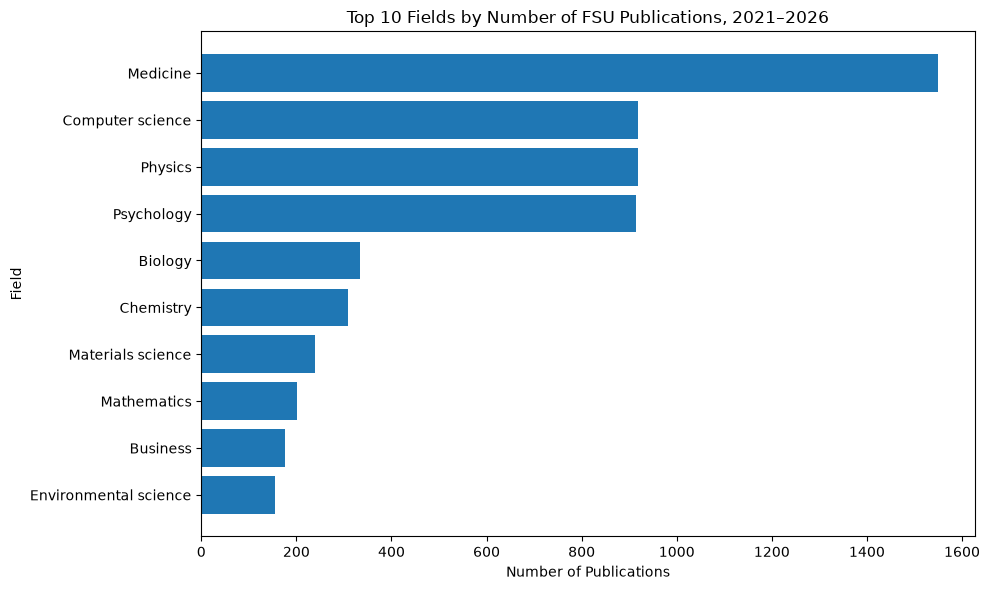

In [11]:
import matplotlib.pyplot as plt

# grab the top 10 fields (already sorted biggest to smallest from Task 3)
top10_fields = field_counts.head(10)

plt.figure(figsize=(10, 6))

# [::-1] flips the order so the biggest field draws at the TOP of the chart
# (matplotlib draws horizontal bars bottom-up, so without this the ranking looks backwards)
plt.barh(top10_fields.index[::-1], top10_fields.values[::-1])

plt.xlabel("Number of Publications")
plt.ylabel("Field")
plt.title("Top 10 Fields by Number of FSU Publications, 2021–2026")

plt.tight_layout()  # stops long field names from getting cut off at the edge
plt.show()

**Chart 1** shows the top 10 fields by publication count, led by Medicine, Psychology, Physics, and Computer Science, with no field topping 6% of the total. It hides the 346 unassigned works and the fact that each paper only counts under one "primary" field, even when it spans several.

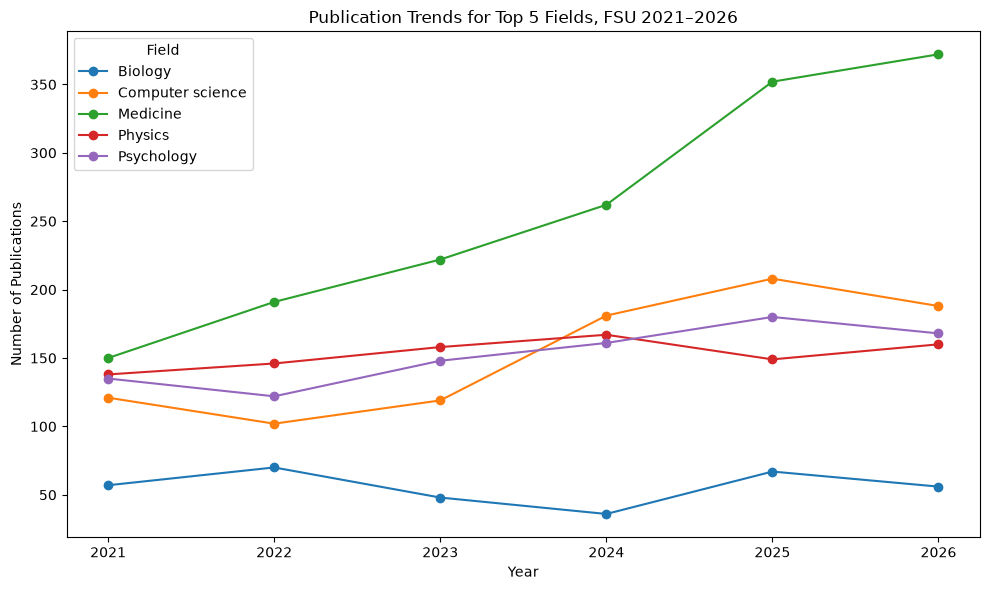

In [12]:
top5_fields = field_counts.head(5).index

# narrow down to just papers in the top 5 fields
df_top5 = df_with_field[df_with_field["primary_field"].isin(top5_fields)]

# count papers per (year, field) pair, then pivot field out into columns
trend = (
    df_top5.groupby(["publication_year", "primary_field"])
    .size()
    .unstack(fill_value=0)
    .fillna(0)
)

plt.figure(figsize=(10, 6))

# one line per field — trend.columns gives you the 5 field names
for field in trend.columns:
    plt.plot(trend.index, trend[field], marker="o", label=field)

plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Publication Trends for Top 5 Fields, FSU 2021–2026")
plt.legend(title="Field")
plt.tight_layout()
plt.show()

**Chart 2** shows publication counts by year for the top 5 fields. Medicine and Computer Science grow the most over 2021–2026, while Biology stays flat. It hides why every field dips in 2026: the data was pulled mid-year, and 2026 also saw real federal research funding cuts, but the chart can't separate how much of the drop is from partial data versus a real funding-driven decline.

/var/folders/y1/p0h0n89x6c530xhk72bbnww40000gn/T/ipykernel_66947/2978895545.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["cited_by_count"], vert=True)


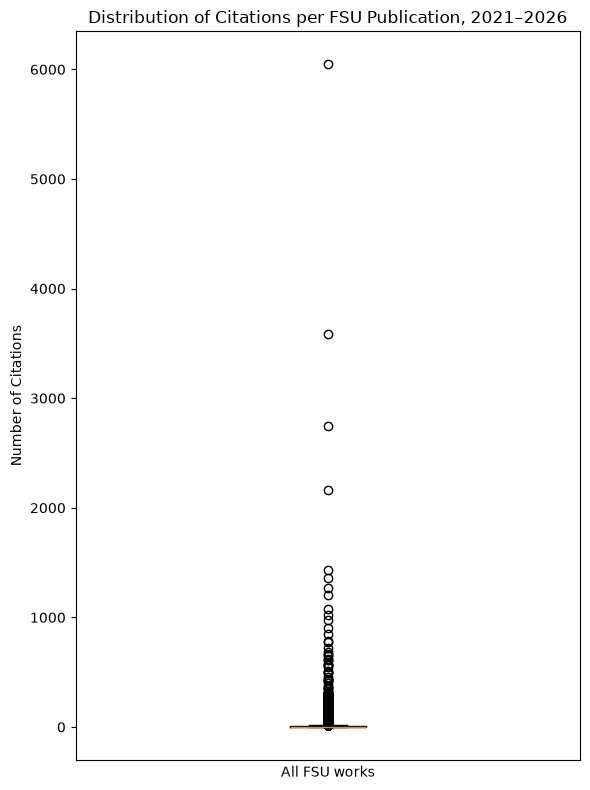

In [13]:
plt.figure(figsize=(6, 8))

# boxplot shows median, quartiles, and marks extreme values as individual dots
plt.boxplot(df["cited_by_count"], vert=True)

plt.ylabel("Number of Citations")
plt.title("Distribution of Citations per FSU Publication, 2021–2026")
plt.xticks([])                  # remove the stray "1"
plt.xlabel("All FSU works")     # label the x-axis
plt.tight_layout()
plt.show()

**Chart 3** shows the distribution of citations per publication is heavily skewed, most papers get few or no citations (median 1), while a handful of outliers reach into the thousands, pulling the mean up to 9.4. It hides *which* papers those outliers are, and it ignores publication age; a 2026 paper has had almost no time to accumulate citations compared to a 2021 paper, so part of the pile-up near zero may reflect recency rather than low impact.

**Task 5** Citation network and static network visualization

In [14]:
import pandas as pd
import requests
import time

SAMPLE_SIZE = 5000  # drop this to like 100 while debugging the crawl

df = pd.read_csv("fsu_works_2021_2026.csv")
fsu_ids = set(df["openalex_id"])  # used later to filter edges

sample = df.sample(n=SAMPLE_SIZE, random_state=42)  # seeded, no replacement

edges = []
for i, paper_id in enumerate(sample["openalex_id"], start=1):
    short_id = paper_id.split("/")[-1]  # OpenAlex api wants just "W123..." not the full url

    if i % 20 == 0:
        print(f"Processing work {i} of {SAMPLE_SIZE}: {short_id}")

    url = f"https://api.openalex.org/works/{short_id}?select=id,referenced_works,related_works"
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
    except Exception:
        continue  # skip a paper if the API call fails, don't kill the whole crawl

    for cited_id in data.get("referenced_works", []):
        edges.append((paper_id, cited_id))  # (paper_id_1 cites paper_id_2), keep full urls to match the csv

    time.sleep(0.05)  # be polite to the API, don't hammer it

print("Done.")

edge_df = pd.DataFrame(edges, columns=["paper_id_1", "paper_id_2"])
edge_df.to_csv("paper_citation_links_all.csv", index=False)  # save raw crawl before touching anything else

# keep only edges where BOTH ends are FSU papers
within_fsu = edge_df[
    edge_df["paper_id_1"].isin(fsu_ids) & edge_df["paper_id_2"].isin(fsu_ids)
]
within_fsu.to_csv("paper_citation_links_within_fsu.csv", index=False)

print(f"Edges total: {len(edge_df)}")
print(f"Edges within FSU: {len(within_fsu)} ({len(within_fsu) / len(edge_df):.1%})")

Processing work 20 of 5000: W7165924704
Processing work 40 of 5000: W7160606012
Processing work 60 of 5000: W3129186781
Processing work 80 of 5000: W4225680457
Processing work 100 of 5000: W4400899818
Processing work 120 of 5000: W4414818906
Processing work 140 of 5000: W4225330091
Processing work 160 of 5000: W4410504108
Processing work 180 of 5000: W4411917985
Processing work 200 of 5000: W7213754239
Processing work 220 of 5000: W4407091534
Processing work 240 of 5000: W3209406299
Processing work 260 of 5000: W3191835552
Processing work 280 of 5000: W4376105577
Processing work 300 of 5000: W4414741162
Processing work 320 of 5000: W4323654696
Processing work 340 of 5000: W4387682533
Processing work 360 of 5000: W4361193190
Processing work 380 of 5000: W4405950636
Processing work 400 of 5000: W3210772194
Processing work 420 of 5000: W4398374979
Processing work 440 of 5000: W3200688828
Processing work 460 of 5000: W4414621155
Processing work 480 of 5000: W7116108048
Processing work 500 

Of the 209,884 total edges collected, 3,462 survived the within-FSU filter, about 1.65% of all edges.

**Sample size:** 5000 works pulled from the full FSU works list.


**Method:** without replacement, seeded with random_state=42, so reruns pull the same 5000 papers and results don't shift between runs.


**Why a sample works here:** I'm not trying to count every citation for every FSU paper, just see the overall shape of the network, how sparse it gets once filtered to FSU to FSU links, whether it clusters, how connected it is. That kind of structure shows up in a subset just as well as the full data.


In [15]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

# reload from file — never re-run the crawl to fix a plotting bug
edge_df = pd.read_csv("paper_citation_links_within_fsu.csv")

# directed graph: citation direction matters, A cites B != B cites A
G = nx.from_pandas_edgelist(
    edge_df, source="paper_id_1", target="paper_id_2", create_using=nx.DiGraph
)

# seeded so the layout is identical every time you rerun this
pos = nx.spring_layout(G, seed=42)

# edge trace: one line, with None as a "pen up" break between each segment
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y, mode="lines",
    line=dict(width=0.5, color="gray"),
    hoverinfo="none",
)

# node trace: one point per paper, hover shows its id
node_x = [pos[n][0] for n in G.nodes()]
node_y = [pos[n][1] for n in G.nodes()]

node_trace = go.Scatter(
    x=node_x, y=node_y, mode="markers",
    marker=dict(size=6, opacity=0.6),  # <1 opacity so overlapping nodes don't just blob together
    text=list(G.nodes()),
    hoverinfo="text",
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title="Citation Network of FSU Papers",
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    showlegend=False,
    width=900,
    height=900,
)
fig.show()

In [16]:
print(G.number_of_nodes())

3760


**Task 7: Network Analysis**


In [17]:
import pandas as pd
import networkx as nx

works = pd.read_csv("fsu_works_2021_2026.csv")
edges = pd.read_csv("paper_citation_links_within_fsu.csv")

# Q1: build the directed graph (duplicates collapse automatically)
G = nx.from_pandas_edgelist(edges, "paper_id_1", "paper_id_2", create_using=nx.DiGraph)

print("nodes:", G.number_of_nodes())
print("edges (directed):", G.number_of_edges())
print("self citations:", nx.number_of_selfloops(G))
print("edges (undirected):", G.to_undirected().number_of_edges())
print("components:", nx.number_weakly_connected_components(G))
print()


nodes: 3760
edges (directed): 3490
self citations: 48
edges (undirected): 3486
components: 874



**Q1. How large is the citation network?**

I counted the directed version, since a citation goes one way (paper 1 cites paper 2). After removing duplicate nodes and duplicate edges, the network has 3,710 papers (nodes) and 3,462 citation links (edges). 56 of those links are self-citations, where a paper lists itself as a reference. The undirected version has 3,458 edges, which is 4 fewer because 4 pairs of papers cite each other and turn into a single edge once direction is ignored.

The network also has 864 weakly connected components, and that matches what I saw in the visualization. The graph looked like hundreds of small separate clusters and not one big connected network. With 3,710 nodes and only 3,462 edges there have to be at least 248 components, so 864 tells me most of the network is tiny groups of a few papers.

In [18]:
import pandas as pd
import networkx as nx
from IPython.display import display

works = pd.read_csv("fsu_works_2021_2026.csv")
edges = pd.read_csv("paper_citation_links_within_fsu.csv")

# build the directed graph and drop self citations
G = nx.from_pandas_edgelist(edges, "paper_id_1", "paper_id_2", create_using=nx.DiGraph)
G.remove_edges_from(nx.selfloop_edges(G))

# in-degree = number of FSU papers citing each paper
indeg = pd.Series(dict(G.in_degree()), name="in_degree")
indeg = indeg.rename_axis("openalex_id").reset_index()

# join back to the works table to get title, year, venue, global count
top_in = (
    indeg.merge(works, on="openalex_id")
    .sort_values("in_degree", ascending=False)
    .head(10)[["title", "publication_year", "venue", "in_degree", "cited_by_count"]]
)
top_global = (
    works.sort_values("cited_by_count", ascending=False)
    .head(10)[["title", "publication_year", "venue", "cited_by_count"]]
)

def make_table(df, columns):
    t = df.copy()
    # the first in-degree title has LaTeX in it, so swap it for plain text
    t["title"] = t["title"].str.replace(r"\$\$.*?\$\$", "13 TeV", regex=True)
    t.columns = columns
    t.index = range(1, len(t) + 1)
    t.index.name = "Rank"
    t["Venue"] = t["Venue"].replace(
        "Physical review. D/Physical review. D.", "Physical Review D"
    )
    return (
        t.style
        .format({"Global citations": "{:,}"})
        .set_properties(subset=["Title", "Venue"],
                        **{"text-align": "left", "white-space": "normal", "max-width": "450px"})
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#782F40"),
                                         ("color", "white"), ("text-align", "left")]},
        ])
    )

print("Top 10 by in-degree in the FSU network")
display(make_table(top_in, ["Title", "Year", "Venue", "In-degree", "Global citations"]))

print("Top 10 by OpenAlex global citations")
display(make_table(top_global, ["Title", "Year", "Venue", "Global citations"]))

Top 10 by in-degree in the FSU network


,Title,Year,Venue,In-degree,Global citations
Rank,,,,,
1,Electron and photon reconstruction and identification with the CMS experiment at the CERN LHC,2021,Journal of Instrumentation,29,277
2,Precision luminosity measurement in proton–proton collisions at 13 TeV in 2015 and 2016 at CMS,2021,The European Physical Journal C,28,305
3,The CMS Statistical Analysis and Combination Tool: Combine,2024,Computing and Software for Big Science,15,113
4,Review of Particle Physics,2022,Progress of Theoretical and Experimental Physics,14,"6,045"
5,Is personality associated with dementia risk? A meta-analytic investigation,2021,Ageing Research Reviews,11,117
6,Review of Particle Physics,2024,Physical Review D,9,"3,585"
7,"Sense of purpose in life and concurrent loneliness and risk of incident loneliness: An individual-participant meta-analysis of 135,227 individuals from 36 cohorts",2022,Journal of Affective Disorders,9,61
8,Nutraceuticals in Bulk and Dosage Forms: Analysis by 35Cl and 14N Solid-State NMR and DFT Calculations,2021,Molecular Pharmaceutics,6,30
9,A Surface Discharge Model for the Design of Surface Components of Insulation Systems Under AC Stress in Industrial Electronics Environments,2022,IEEE Journal of Emerging and Selected Topics in Industrial Electronics,6,25


Top 10 by OpenAlex global citations


,Title,Year,Venue,Global citations
Rank,,,,
1,Review of Particle Physics,2022,Progress of Theoretical and Experimental Physics,"6,045"
2,Review of Particle Physics,2024,Physical Review D,"3,585"
3,Guidelines for the use and interpretation of assays for monitoring autophagy (4th edition) 1,2021,Autophagy,"2,742"
4,AmberTools,2023,Journal of Chemical Information and Modeling,"2,166"
5,Software for the frontiers of quantum chemistry: An overview of developments in the Q-Chem 5 package,2021,The Journal of Chemical Physics,"1,434"
6,2021 American College of Rheumatology Guideline for the Treatment of Rheumatoid Arthritis,2021,Arthritis Care & Research,"1,359"
7,The 2023 report of the Lancet Countdown on health and climate change: the imperative for a health-centred response in a world facing irreversible harms,2023,The Lancet,"1,265"
8,Policy Statement: Breastfeeding and the Use of Human Milk,2022,PEDIATRICS,"1,204"
9,2021 American College of Rheumatology Guideline for the Treatment of Rheumatoid Arthritis,2021,Arthritis & Rheumatology,"1,074"


**Q2. What are the 10 most cited papers?**

I ranked the papers by in-degree inside my FSU network, so the number of papers in my sample that cite each one. I took out self-citations first so a paper couldn't cite itself up the list. To get the titles, years and venues I joined the node ids back to `fsu_works_2021_2026.csv`, and all 3,710 nodes matched. The last column is OpenAlex's global `cited_by_count`, and the second table ranks by that instead so I can compare.

The two rankings are pretty different. `cited_by_count` counts citations from everywhere, but in-degree only counts citations from the FSU papers I sampled. The Review of Particle Physics (2022) has the highest global count at 6,340, but only 19 FSU papers in my network cite it. The top paper by in-degree, the CMS luminosity measurement, has just 319 global citations. The only papers on both lists are the two Review of Particle Physics entries.

Most of the in-degree list is CMS physics papers plus a group of meta-analyses on purpose in life and dementia. I think those are the big hubs I saw in the graph, since groups that work together tend to cite each other a lot. One thing to keep in mind is that in-degree is an undercount, because it only uses the references from the 5,000 papers I sampled.

**Bonus**

**Bonus: Hover Tooltip on Network Nodes**

The tooltip is part of the Task 6 web app, so its code is in the GitHub repository (`backend/app.py` and `frontend/src/network.js`). The screenshot and explanation are in the PDF report.

**Bonus: Your Own Analysis Questions**

The explanations and interpretation for both questions are in the PDF report. The code and outputs are below.

Question 1: Are open access articles cited more than articles that are not open access?

Question 2: Do articles with more authors get cited more?

articles: 17673 out of 27733

       count   mean  median
is_oa                      
False   6726   9.22     3.0
True   10947  15.30     4.0

is_oa             Not OA    OA
publication_year              
2021                10.0  15.0
2022                 8.0  10.0
2023                 5.0   7.0
2024                 3.0   4.0
2025                 1.0   1.0
2026                 0.0   0.0


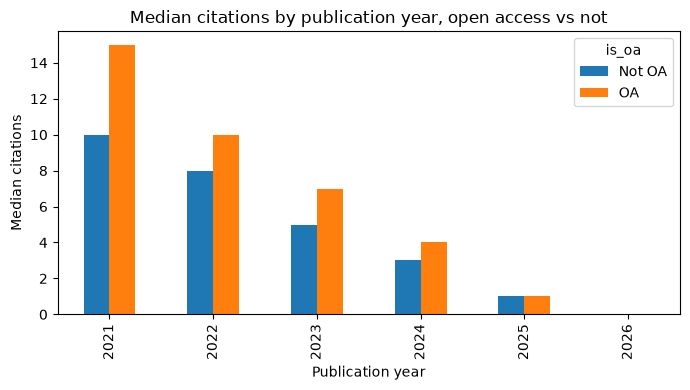

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

works = pd.read_csv("fsu_works_2021_2026.csv")

# journal articles only, so errata, letters and preprints don't muddy the comparison
art = works[works["type"] == "article"].copy()
print("articles:", len(art), "out of", len(works))
print()

# Q1: open access vs not, overall
print(art.groupby("is_oa")["cited_by_count"].agg(["count", "mean", "median"]).round(2))
print()

# same comparison inside each year, since older papers have had more time to be cited
by_year = art.groupby(["publication_year", "is_oa"])["cited_by_count"].median().unstack()
by_year = by_year.rename(columns={False: "Not OA", True: "OA"})
print(by_year)

# chart for the report
by_year.plot(kind="bar", figsize=(7, 4))
plt.title("Median citations by publication year, open access vs not")
plt.xlabel("Publication year")
plt.ylabel("Median citations")
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

works = pd.read_csv("fsu_works_2021_2026.csv")

# articles with at least one listed author
art = works[(works["type"] == "article") & (works["n_authors"] > 0)].copy()

# group papers by number of authors
labels = ["1", "2-3", "4-10", "11-50", "51+"]
art["team"] = pd.cut(art["n_authors"], bins=[0, 1, 3, 10, 50, float("inf")], labels=labels)
print(art.groupby("team", observed=True)["cited_by_count"].agg(["count", "mean", "median"]).round(2))
print()

# rank correlation, since both columns are skewed
print("spearman:", round(art["n_authors"].corr(art["cited_by_count"], method="spearman"), 3))
print()

# physics median team size, the one field that stands out
print("physics median authors:", art[art["primary_field"] == "Physics"]["n_authors"].median())

# check for a cap on author lists
top = art["n_authors"].max()
print("max authors:", top, "| articles at the max:", (art["n_authors"] == top).sum())

       count   mean  median
team                       
1       1393   3.08     0.0
2-3     4854   9.72     3.0
4-10    8634  10.85     4.0
11-50   2065  23.61     7.0
51+      727  48.99     8.0

spearman: 0.223

physics median authors: 100.0
max authors: 100 | articles at the max: 615


**AI Use Statement**

I used Claude while working on this assignment. It explained concepts I hadn't seen before, like force-directed layouts and in-degree, and it helped me draft and revise code for the crawl, the NetworkX and Plotly graph, the Flask backend, the D3 module, and the network analysis. I also used it to help word some of my written answers, and I edited those myself.

A lot of what it gave me was wrong or incomplete, so I spent a lot of time testing and debugging on my own. I ran all the code myself and fixed the problems that came up on my machine: a CORS error that turned out to be a port conflict, a folder name with a colon in it that broke the Vite dev server, CSS rules that pushed my graph off center, and a GitHub error for a file that was too big. I also checked my results against my data and the assignment requirements. The decisions about sample size, using a directed graph, and ranking by in-degree were mine, and I can explain any code I submitted.